In [1]:
import tensorflow as tf

In [2]:
cifar100 = tf.keras.datasets.cifar100

In [3]:
cifar100

<module 'keras.datasets.cifar100' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/cifar100/__init__.py'>

In [4]:
(training_images, training_labels), (test_images, test_labels) = cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 11271s 67us/step



IMAGE PIXEL ARRAY:
 [[[124 194 221]
  [131 202 228]
  [135 206 228]
  ...
  [149 225 236]
  [143 220 234]
  [136 213 230]]

 [[121 194 220]
  [128 201 225]
  [134 206 228]
  ...
  [151 224 234]
  [146 222 234]
  [142 217 232]]

 [[122 197 223]
  [129 204 228]
  [136 208 229]
  ...
  [156 228 236]
  [153 226 237]
  [148 221 235]]

 ...

 [[129  42  59]
  [147  17  38]
  [151  16  30]
  ...
  [234 231 225]
  [238 240 233]
  [224 197 201]]

 [[150  21  40]
  [152  17  33]
  [156  25  36]
  ...
  [227 225 221]
  [231 241 233]
  [231 236 230]]

 [[147  12  25]
  [146  11  23]
  [156  15  29]
  ...
  [230 237 232]
  [243 237 236]
  [243 230 231]]]
LABEL: [11]


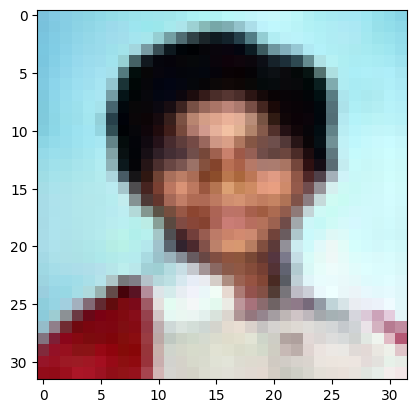

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# You can put between 0 to 59999 here
index = 3

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'\nIMAGE PIXEL ARRAY:\n {training_images[index]}')

# Visualize the image
print(f'LABEL: {training_labels[index]}')
plt.imshow(training_images[index])
plt.show()

In [6]:
# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0

In [9]:
# Build the classification model
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                     tf.keras.layers.Dense(64, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(100, activation=tf.nn.softmax)])

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,224,302 (4.67 MB)

 Trainable params: 408,100 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 816,202 (3.11 MB)

In [10]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images, training_labels, epochs=100)

Epoch 1/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.0555 - loss: 4.2257
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1114 - loss: 3.8283
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1380 - loss: 3.6742
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1555 - loss: 3.5724
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.1660 - loss: 3.4999
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1773 - loss: 3.4506
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1818 - loss: 3.4145
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1907 - loss: 3.3784
Epoch 9/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1931 - loss: 3.3559
Epoch 10/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1959 - loss: 3.3348
Epoch 11/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.2029 - loss: 3.3128
Epoch 12

In [11]:
# Evaluate the model on unseen data
model.evaluate(test_images, test_labels)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1920 - loss: 3.6559


[3.6558737754821777, 0.19200000166893005]

In [12]:

classifications = model.predict(test_images)

print(classifications[34])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[6.5712403e-03 8.3115175e-03 1.1775156e-02 1.8154258e-02 1.2948200e-02 2.9668049e-03 4.0543918e-02 1.1382583e-02 2.9716003e-03 1.7177364e-03 2.0091414e-02 4.4153864e-03 5.9002890e-05 3.7821389e-03 2.8620805e-03 1.7319659e-02 6.4093801e-03 2.8752352e-04 6.7852158e-03 2.8182480e-03 4.1732197e-03 3.8689283e-05
 3.6324395e-03 9.9626690e-05 2.2962091e-03 7.2053946e-03 1.2391031e-02 3.0365540e-03 6.8245102e-03 3.4869868e-02 2.2119656e-07 3.3480772e-03 3.0912312e-02 5.8551796e-04 9.1795824e-02 7.6508559e-03 2.5661677e-02 9.0233661e-04 6.5940982e-03 1.4978170e-03 2.3153333e-03 3.9496538e-04 4.9289078e-02 2.9673824e-02
 3.2020036e-02 1.3909738e-02 2.2446115e-03 2.3156467e-03 8.3563793e-03 8.2818697e-05 2.7152214e-02 1.0432836e-02 1.2078594e-04 3.5981683e-03 3.4266035e-03 4.2550196e-03 5.4384475e-03 1.5490213e-02 5.4671132e-04 1.5911149e-03 5.9156700e-06 5.1669190e-03 1.1957729e-03 1.4037751e-02 8.0586076e-03 9.8097660e-03
 2.7238387e-03 1.1993608e-02 9.4

In [13]:
print(test_labels[3])

[51]


Saving bear-768x512.jpg to bear-768x512.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


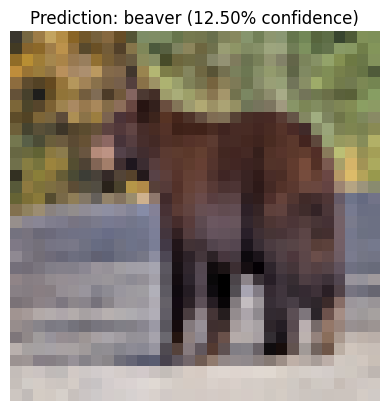

Uploaded file: bear-768x512.jpg
Predicted class number: 4
Predicted class name: beaver
Confidence: 12.50%
All class probabilities:
apple: 0.01%
aquarium_fish: 0.08%
baby: 5.43%
bear: 3.00%
beaver: 12.50%
bed: 0.39%
bee: 0.69%
beetle: 0.50%
bicycle: 4.64%
bottle: 0.32%
bowl: 0.40%
boy: 3.15%
bridge: 0.00%
bus: 0.40%
butterfly: 0.32%
camel: 0.43%
can: 0.75%
castle: 0.00%
caterpillar: 0.11%
cattle: 0.30%
chair: 0.22%
chimpanzee: 0.63%
clock: 0.00%
cloud: 0.00%
cockroach: 0.25%
couch: 0.48%
crab: 0.18%
crocodile: 0.32%
cup: 0.25%
dinosaur: 0.76%
dolphin: 0.05%
elephant: 2.42%
flatfish: 1.39%
forest: 0.04%
fox: 1.41%
girl: 2.17%
hamster: 0.06%
house: 0.04%
kangaroo: 2.48%
keyboard: 0.16%
lamp: 0.02%
lawn_mower: 0.14%
leopard: 0.34%
lion: 0.01%
lizard: 2.03%
lobster: 1.59%
man: 3.95%
maple_tree: 0.03%
motorcycle: 6.19%
mountain: 0.00%
mouse: 1.53%
mushroom: 0.07%
oak_tree: 0.00%
orange: 0.00%
orchid: 0.00%
otter: 1.96%
palm_tree: 0.15%
pear: 0.15%
pickup_truck: 0.19%
pine_tree: 0.09%
plain: 

In [16]:
# Upload your own image and predict the CIFAR-100 class
# Run this cell AFTER training the model.

from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-100 has 100 classes. These are the fine-grained labels.
cifar100_fine_class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle",
    "bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel",
    "can", "castle", "caterpillar", "cattle", "chair", "chimpanzee", "clock",
    "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster",
    "house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion",
    "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse",
    "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear",
    "pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine",
    "possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea",
    "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "stock_car", "sunflower", "sweet_pepper", "table", "tank",
    "telephone", "television", "tiger", "tractor", "train", "trout", "tulip",
    "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

# Upload an image file: png, jpg, jpeg, etc.
uploaded = files.upload()

for file_name in uploaded.keys():
    # 1. Open uploaded image
    # CIFAR-100 images are RGB, so convert to RGB.
    img = Image.open(file_name).convert("RGB")

    # 2. Resize image to 32 x 32 because CIFAR-100 images are 32x32
    img = img.resize((32, 32))

    # 3. Remove image inversion as it's not typical for CIFAR-100
    # img = ImageOps.invert(img) # This line was for Fashion MNIST

    # 4. Convert image into numpy array and normalize values from 0 to 1
    img_array = np.array(img) / 255.0

    # 5. Add batch dimension: model expects shape (1, 32, 32, 3)
    img_input = np.expand_dims(img_array, axis=0)

    # 6. Predict
    prediction = model.predict(img_input)
    predicted_index = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    # 7. Show result
    plt.imshow(img_array) # Display RGB image directly
    plt.axis("off")
    # Use CIFAR-100 class names
    plt.title(f"Prediction: {cifar100_fine_class_names[predicted_index]} ({confidence:.2f}% confidence)")
    plt.show()

    print("Uploaded file:", file_name)
    print("Predicted class number:", predicted_index)
    print("Predicted class name:", cifar100_fine_class_names[predicted_index])
    print(f"Confidence: {confidence:.2f}%")
    print("All class probabilities:")
    for name, prob in zip(cifar100_fine_class_names, prediction[0]):
        print(f"{name}: {prob*100:.2f}%")